# M1 - Dense Autoencoder + MC Dropout

---
## Section 1 - Setup

In [1]:
%pip install -q -r requirements.txt


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ── Environment ───────────────────────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ── Datasets ──────────────────────────────────────────────────────────────────
DATASETS = {
    "SKAB": {
        "npy_dir":     "npy_skab",
        "hf_dataset":  "skab-anomaly-detection",
        "window_size": 30,
        "n_features":  8,
    },
    "NAB": {
        "npy_dir":     "npy_nab",
        "hf_dataset":  "nab-anomaly-detection",
        "window_size": 50,
        "n_features":  1,
    },
}

# ── Hyperparameter grid ────────────────────────────────────────────────────────
# Full grid = 3×3×3 = 27 combos per dataset.
# Set MAX_HP_RUNS to an int to random-sample N configs instead (e.g. 12 on CPU).
HP_GRID = {
    "dropout_p":  [0.05, 0.10, 0.20],   # MC Dropout rate
    "latent_dim": [16, 32, 64],          # AE bottleneck size
    "lr":         [5e-4, 1e-3, 2e-3],    # Adam learning rate
}
MAX_HP_RUNS = None   # None = full grid; int = random sample N combos

# ── Fixed training hyperparameters ────────────────────────────────────────────
EPOCHS     = 100
BATCH_SIZE = 256
PATIENCE   = 10    # early stopping patience (epochs without val improvement)
T_MC       = 50    # stochastic forward passes at inference

# ── Checkpointing ─────────────────────────────────────────────────────────────
# During HP search → local saves only; winner pushed to HF once per dataset.
# Total HF commits = n_datasets (2) regardless of grid size.
PUSH_TO_HUB           = True
MODEL_REPO_NAME       = "iot-ad-models"
CKPT_IMPROVEMENT_THR  = 0.10   # for final best-model run: push when val drops ≥10%
MAX_INTERMEDIATE_CKPTS = 4     # max intermediate HF pushes for final run; +1 final = 5

# ── Evaluation ────────────────────────────────────────────────────────────────
THRESHOLD_PCT = 95    # val-set percentile for binary threshold

# ── W&B ───────────────────────────────────────────────────────────────────────
USE_WANDB     = True
WANDB_PROJECT = "iot-ad-mcd"
WANDB_ENTITY  = ""   # filled from os.getenv("WANDB_ENTITY") in next cell

# ── Misc ──────────────────────────────────────────────────────────────────────
SEED        = 42
OUTPUT_DIR  = "outputs"
CKPT_DIR    = "models/checkpoints"
RESULTS_FILE = f"{OUTPUT_DIR}/baseline_results.json"

In [3]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    f1_score, precision_recall_curve,
)
from huggingface_hub import HfApi, create_repo

# ── Credentials ───────────────────────────────────────────────────────────────
if IN_COLAB:
    # Option 1 - Colab Secrets panel (left sidebar > key icon)
    try:
        from google.colab import userdata
        HF_USERNAME  = userdata.get("HF_USERNAME")
        HF_TOKEN     = userdata.get("HF_TOKEN")
        WANDB_KEY    = userdata.get("WANDB_API_KEY", "")
        WANDB_ENTITY = userdata.get("WANDB_ENTITY", "")
    except Exception:
        # Option 2 - set manually before running
        HF_USERNAME  = os.getenv("HF_USERNAME", "")
        HF_TOKEN     = os.getenv("HF_TOKEN", "")
        WANDB_KEY    = os.getenv("WANDB_API_KEY", "")
        WANDB_ENTITY = os.getenv("WANDB_ENTITY", "")
    if USE_WANDB:
        import wandb
        if WANDB_KEY:
            wandb.login(key=WANDB_KEY)
        else:
            wandb.login()   # will prompt for key
else:
    from dotenv import load_dotenv
    load_dotenv()
    HF_USERNAME="ayyoubsoullami"
    HF_TOKEN=""
    WANDB_KEY="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"
    WANDB_ENTITY="soullamiayyoub"
    if USE_WANDB:
        import wandb   # uses credentials from ~/.netrc (already logged in)

if not HF_USERNAME or not HF_TOKEN:
    raise EnvironmentError(
        "HF_USERNAME or HF_TOKEN not found. "
        "Local: add to .env | Colab: add to Secrets panel."
    )

# ── Setup ─────────────────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 10})
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR,   exist_ok=True)

api           = HfApi()
MODEL_REPO_ID = f"{HF_USERNAME}/{MODEL_REPO_NAME}"

print(f"Environment  : {'Google Colab' if IN_COLAB else 'Local'}")
print(f"Device       : {device}")
print(f"HF_USERNAME  : {HF_USERNAME}")
print(f"Model repo   : {MODEL_REPO_ID}")
if USE_WANDB:
    _ent = WANDB_ENTITY or "(W&B default - set WANDB_ENTITY in .env if this errors)"
    print(f"W&B project  : {WANDB_PROJECT}  entity={_ent}")
else:
    print(f"W&B project  : (disabled)")
print("Imports OK")

Environment  : Local
Device       : cuda
HF_USERNAME  : ayyoubsoullami
Model repo   : ayyoubsoullami/iot-ad-models
W&B project  : iot-ad-mcd  entity=soullamiayyoub
Imports OK


In [4]:
# Idempotent - safe to re-run; exist_ok=True silently skips if repo exists
try:
    create_repo(
        repo_id   = MODEL_REPO_ID,
        repo_type = "model",
        token     = HF_TOKEN,
        private   = False,
        exist_ok  = True,
    )
    print(f"HF model repo ready  : https://huggingface.co/{MODEL_REPO_ID}")
    print(f"Checkpoints folder   : {MODEL_REPO_ID}/checkpoints/")
except Exception as e:
    print(f"WARNING: could not verify HF repo - {e}")
    print("Checkpoints will be saved locally only (PUSH_TO_HUB will be ignored).")

HF model repo ready  : https://huggingface.co/ayyoubsoullami/iot-ad-models
Checkpoints folder   : ayyoubsoullami/iot-ad-models/checkpoints/


---
## Section 2 - Data Loading

In [5]:
def _load_local(ds_name, cfg):
    """Load npy arrays from local disk."""
    npy_dir = cfg["npy_dir"]
    if not os.path.isdir(npy_dir):
        print(f"  WARNING: '{npy_dir}' not found - skipping {ds_name}.")
        return None
    arrays = {}
    for name in ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]:
        path = os.path.join(npy_dir, f"{name}.npy")
        if not os.path.exists(path):
            print(f"  WARNING: {path} missing - skipping {ds_name}.")
            return None
        arrays[name] = np.load(path)
    return arrays


def _load_from_hub(ds_name, cfg):
    """Load windowed arrays from HuggingFace Hub (Colab path)."""
    from datasets import load_dataset as hf_load
    repo = f"{HF_USERNAME}/{cfg['hf_dataset']}"
    print(f"  Fetching {ds_name} from HF Hub: {repo} ...")
    try:
        ds = hf_load(repo)
    except Exception as e:
        print(f"  HF load failed ({e}) - falling back to local npy.")
        return _load_local(ds_name, cfg)

    n_feat = cfg["n_features"]

    def to_np(split):
        X = np.stack(
            [np.array(split[f"feature_{i}"]) for i in range(n_feat)], axis=-1
        ).astype(np.float32)
        y = np.array(split["label"], dtype=np.int8)
        return X, y

    X_train, y_train = to_np(ds["train"])
    X_val,   y_val   = to_np(ds["validation"])
    X_test,  y_test  = to_np(ds["test"])
    return dict(
        X_train=X_train, X_val=X_val, X_test=X_test,
        y_train=y_train, y_val=y_val, y_test=y_test,
    )


def load_dataset_arrays(ds_name, cfg):
    return _load_from_hub(ds_name, cfg) if IN_COLAB else _load_local(ds_name, cfg)


# ── Execute ────────────────────────────────────────────────────────────────────
data = {}
for ds_name, cfg in DATASETS.items():
    print(f"\n{'='*50}\n{ds_name}")
    arr = load_dataset_arrays(ds_name, cfg)
    if arr is not None:
        data[ds_name] = arr
        for k, v in arr.items():
            print(f"  {k}: {v.shape}  dtype={v.dtype}")

print(f"\nDatasets loaded: {list(data.keys())}")


SKAB
  X_train: (23588, 30, 8)  dtype=float32
  X_val: (3345, 30, 8)  dtype=float32
  X_test: (19786, 30, 8)  dtype=float32
  y_train: (23588,)  dtype=int8
  y_val: (3345,)  dtype=int8
  y_test: (19786,)  dtype=int8

NAB
  X_train: (229577, 50, 1)  dtype=float32
  X_val: (30354, 50, 1)  dtype=float32
  X_test: (97101, 50, 1)  dtype=float32
  y_train: (229577,)  dtype=int8
  y_val: (30354,)  dtype=int8
  y_test: (97101,)  dtype=int8

Datasets loaded: ['SKAB', 'NAB']


---
## Section 3 - Model Architecture

In [6]:
class DenseAE(nn.Module):
    """Dense autoencoder with configurable dropout.

    dropout_p = 0.0  +  model.eval()   →  deterministic (B3)
    dropout_p > 0.0  +  model.train()  →  MC Dropout    (M1)
    """

    def __init__(self, input_dim: int, latent_dim: int = 32,
                 dropout_p: float = 0.0):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(128, 64),        nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(64, latent_dim), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(64, 128),        nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(128, input_dim), nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(x))

---
## Section 4 - Training & Checkpointing Helpers

In [7]:
def push_checkpoint(model, filename, commit_msg):
    """Save model state locally; optionally upload to HF Hub."""
    local_path = os.path.join(CKPT_DIR, filename)
    torch.save(model.state_dict(), local_path)
    if not PUSH_TO_HUB:
        return
    try:
        api.upload_file(
            path_or_fileobj = local_path,
            path_in_repo    = f"checkpoints/{filename}",
            repo_id         = MODEL_REPO_ID,
            repo_type       = "model",
            token           = HF_TOKEN,
            commit_message  = commit_msg,
        )
        print(f"      ↑ HF: checkpoints/{filename}")
    except Exception as e:
        print(f"      ⚠ HF push failed ({filename}): {e}")

In [8]:
def train_mcd(model, X_train, X_val, run_label, hp, wandb_run=None,
              push_to_hf=False):
    """Train Dense AE with MC Dropout.

    Parameters
    ----------
    hp : dict  {"dropout_p": float, "latent_dim": int, "lr": float}
    push_to_hf : bool
        False during HP search (local saves only).
        True for the final winner run (smart intermediate + 1 final HF push).

    Checkpointing
    -------------
    push_to_hf=False → saves best weights to local .pt after training (no HF)
    push_to_hf=True  → smart HF pushes (≤ MAX_INTERMEDIATE_CKPTS+1 commits)
        • intermediate: push when val drops ≥ CKPT_IMPROVEMENT_THR vs last push
        • final:        push _best.pt exactly once after load_state_dict

    Returns
    -------
    (model, train_losses, val_losses, best_val_loss, local_ckpt_path)
    """
    dropout_p  = hp["dropout_p"]
    latent_dim = hp["latent_dim"]
    lr         = hp["lr"]
    hp_tag     = f"dp{dropout_p}_ld{latent_dim}_lr{lr:.0e}"

    t_tens = torch.from_numpy(X_train.reshape(len(X_train), -1)).float()
    v_tens = torch.from_numpy(X_val.reshape(len(X_val),   -1)).float()
    t_dl   = DataLoader(TensorDataset(t_tens), batch_size=BATCH_SIZE, shuffle=True)
    v_dl   = DataLoader(TensorDataset(v_tens), batch_size=BATCH_SIZE)

    opt  = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()

    best_val, best_state, patience_ctr = float("inf"), None, 0
    train_losses, val_losses            = [], []

    last_pushed_val = float("inf")
    n_intermediate  = 0

    for epoch in range(EPOCHS):
        # ── train (dropout active) ─────────────────────────────────────────────
        model.train()
        ep_loss = 0.0
        for (xb,) in t_dl:
            xb   = xb.to(device)
            loss = crit(model(xb), xb)
            opt.zero_grad(); loss.backward(); opt.step()
            ep_loss += loss.item() * len(xb)
        tl = ep_loss / len(t_tens)

        # ── validate (dropout off - deterministic) ─────────────────────────────
        model.eval()
        with torch.no_grad():
            vl = sum(
                crit(model(xb.to(device)), xb.to(device)).item() * len(xb)
                for (xb,) in v_dl
            ) / len(v_tens)

        train_losses.append(tl)
        val_losses.append(vl)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"    [{run_label}|{hp_tag}] ep {epoch+1:3d}/{EPOCHS}"
                  f"  train={tl:.5f}  val={vl:.5f}  best={best_val:.5f}")

        if wandb_run:
            wandb_run.log({"train_loss": tl, "val_loss": vl,
                           "epoch": epoch + 1, "best_val": best_val})

        # ── track best in RAM ──────────────────────────────────────────────────
        if vl < best_val - 1e-6:
            best_val     = vl
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        # ── smart HF intermediate checkpoint (winner run only) ─────────────────
        if push_to_hf and n_intermediate < MAX_INTERMEDIATE_CKPTS:
            rel_drop     = (last_pushed_val - vl) / (last_pushed_val + 1e-9)
            cond_big_drop = rel_drop >= CKPT_IMPROVEMENT_THR
            cond_overfit  = patience_ctr == 1 and epoch > 0
            if cond_big_drop or cond_overfit:
                reason = "big_drop" if cond_big_drop else "overfit_signal"
                push_checkpoint(
                    model,
                    f"{run_label}_{hp_tag}_ep{epoch+1:03d}.pt",
                    f"[{reason}] {run_label} {hp_tag} ep={epoch+1} val={vl:.6f}",
                )
                last_pushed_val = vl
                n_intermediate += 1

        if patience_ctr >= PATIENCE:
            print(f"    [{run_label}|{hp_tag}] Early stop ep {epoch + 1}"
                  f"  best val={best_val:.5f}")
            break

    # ── restore best weights ───────────────────────────────────────────────────
    model.load_state_dict(best_state)

    # ── save locally (always - crash recovery for HP search) ──────────────────
    local_path = os.path.join(CKPT_DIR, f"{run_label}_{hp_tag}.pt")
    torch.save(model.state_dict(), local_path)

    # ── push to HF (winner run only) ───────────────────────────────────────────
    if push_to_hf:
        push_checkpoint(
            model,
            f"{run_label}_{hp_tag}_best.pt",
            f"Best {run_label} {hp_tag} val={best_val:.6f}"
            f" | {n_intermediate} intermediate ckpts",
        )
        print(f"    [{run_label}|{hp_tag}] Done - "
              f"{n_intermediate} intermediate + 1 final = "
              f"{n_intermediate + 1} HF commits.")
    else:
        print(f"    [{run_label}|{hp_tag}] Done - "
              f"val={best_val:.5f}  saved locally → {local_path}")

    return model, train_losses, val_losses, best_val, local_path

In [9]:
def mcd_scores(model, X, T=T_MC, batch_size=512):
    """T stochastic forward passes with dropout active.

    Returns dict:
      'mean'  (n_windows,)   - point-estimate anomaly score
      'std'   (n_windows,)   - uncertainty (spread across T passes)
      'all'   (T, n_windows) - raw per-pass errors
    """
    model.train()   # ← keep dropout ACTIVE - key difference from B3 model.eval()
    X_flat = torch.from_numpy(X.reshape(len(X), -1)).float()

    pass_errors = []
    with torch.no_grad():
        for t in range(T):
            errs = []
            dl   = DataLoader(TensorDataset(X_flat), batch_size=batch_size)
            for (xb,) in dl:
                xb  = xb.to(device)
                err = ((xb - model(xb)) ** 2).mean(dim=1)
                errs.append(err.cpu().numpy())
            pass_errors.append(np.concatenate(errs))
            if (t + 1) % 10 == 0:
                print(f"  MC pass {t + 1}/{T}", end="\r")

    all_errors = np.stack(pass_errors)   # (T, n_windows)
    print(f"  MC Dropout: {T} passes complete.          ")
    return {
        "mean": all_errors.mean(axis=0),
        "std":  all_errors.std(axis=0),
        "all":  all_errors,
    }

---
## Section 5 - Hyperparameter Search

In [10]:
import itertools, random as _random

def _build_hp_combos():
    """Return list of hp dicts; random-sample if MAX_HP_RUNS is set."""
    combos = [
        {"dropout_p": dp, "latent_dim": ld, "lr": lr}
        for dp, ld, lr in itertools.product(
            HP_GRID["dropout_p"], HP_GRID["latent_dim"], HP_GRID["lr"]
        )
    ]
    if MAX_HP_RUNS is not None and MAX_HP_RUNS < len(combos):
        _random.seed(SEED)
        combos = _random.sample(combos, MAX_HP_RUNS)
    return combos


def _hp_key(hp):
    return f"dp{hp['dropout_p']}_ld{hp['latent_dim']}_lr{hp['lr']:.0e}"


sweep_results = {}   # {ds_name: {hp_key: {hp, val_loss, train_losses, val_losses, local_ckpt}}}
best_models   = {}   # {ds_name: {hp, val_loss, train_losses, val_losses, model}}

hp_combos = _build_hp_combos()
print(f"HP search: {len(hp_combos)} combos per dataset "
      f"({'full grid' if MAX_HP_RUNS is None else f'random sample of {MAX_HP_RUNS}'})")
print(f"Grid: dropout_p={HP_GRID['dropout_p']}  "
      f"latent_dim={HP_GRID['latent_dim']}  lr={HP_GRID['lr']}\n")

# ── Loop over datasets ────────────────────────────────────────────────────────
for ds_name, cfg in DATASETS.items():
    if ds_name not in data:
        print(f"Skipping {ds_name} - data not loaded.")
        continue

    arr       = data[ds_name]
    X_train   = arr["X_train"]
    X_val     = arr["X_val"]
    input_dim = X_train.shape[1] * X_train.shape[2]
    run_label = f"dense_ae_mcd_{ds_name.lower()}"

    print(f"\n{'='*70}")
    print(f"  {ds_name}   input_dim={input_dim}   {len(hp_combos)} combos")
    print(f"{'='*70}")

    # ── load partial results (crash recovery) ─────────────────────────────────
    partial_file = f"{OUTPUT_DIR}/hp_partial_{ds_name.lower()}.json"
    try:
        with open(partial_file) as f:
            partial = json.load(f)
        sweep_results[ds_name] = partial
        print(f"  Resumed from {partial_file}: "
              f"{len(partial)}/{len(hp_combos)} combos already done.\n")
    except FileNotFoundError:
        sweep_results[ds_name] = {}

    # ── iterate over all HP combos ────────────────────────────────────────────
    for i, hp in enumerate(hp_combos):
        key = _hp_key(hp)

        # skip if this combo's local checkpoint already exists (crash recovery)
        local_ckpt = os.path.join(CKPT_DIR, f"{run_label}_{key}.pt")
        if key in sweep_results[ds_name] and os.path.exists(local_ckpt):
            vl = sweep_results[ds_name][key]["val_loss"]
            print(f"  [{i+1:2d}/{len(hp_combos)}] ✓ (cached)  {key}  val={vl:.6f}")
            continue

        print(f"\n  [{i+1:2d}/{len(hp_combos)}]  {key}")

        wandb_run = None
        if USE_WANDB:
            try:
                wandb_run = wandb.init(
                    project = WANDB_PROJECT,
                    entity  = WANDB_ENTITY or None,
                    name    = f"M1_{ds_name}_{key}",
                    config  = {
                        "method":      "Dense_AE_MCD",
                        "dataset":     ds_name,
                        **hp,
                        "T_MC":        T_MC,
                        "epochs":      EPOCHS,
                        "patience":    PATIENCE,
                        "batch_size":  BATCH_SIZE,
                        "window_size": cfg["window_size"],
                        "n_features":  cfg["n_features"],
                        "in_colab":    IN_COLAB,
                    },
                    reinit = True,
                )
            except Exception as e:
                print(f"  ⚠ W&B init failed ({e}) - continuing without tracking.")
                wandb_run = None

        model = DenseAE(input_dim, hp["latent_dim"], hp["dropout_p"]).to(device)
        model, t_losses, v_losses, best_val, ckpt_path = train_mcd(
            model, X_train, X_val, run_label, hp, wandb_run,
            push_to_hf=False,   # no HF during search - winner gets pushed at end
        )

        if wandb_run:
            wandb_run.summary["best_val_loss"] = best_val
            wandb_run.summary["n_epochs_run"]  = len(t_losses)
            wandb_run.finish()

        sweep_results[ds_name][key] = {
            "hp":          hp,
            "val_loss":    best_val,
            "train_losses": t_losses,
            "val_losses":  v_losses,
            "local_ckpt":  ckpt_path,
        }

        # Save partial results to JSON after each combo (no model object - not serialisable)
        with open(partial_file, "w") as f:
            json.dump(sweep_results[ds_name], f, indent=2)

        print(f"  → val={best_val:.6f}  ({len(t_losses)} epochs)  "
              f"[{i+1}/{len(hp_combos)} done]")

    # ── pick best combo ───────────────────────────────────────────────────────
    best_key = min(sweep_results[ds_name],
                   key=lambda k: sweep_results[ds_name][k]["val_loss"])
    best_entry = sweep_results[ds_name][best_key]
    best_hp    = best_entry["hp"]

    print(f"\n  {'─'*60}")
    print(f"  ✅ Best combo : {best_key}")
    print(f"     val_loss   : {best_entry['val_loss']:.6f}")

    # ── load best model from local checkpoint ────────────────────────────────
    best_model = DenseAE(input_dim, best_hp["latent_dim"], best_hp["dropout_p"]).to(device)
    best_model.load_state_dict(torch.load(best_entry["local_ckpt"], map_location=device))
    best_model.eval()

    # ── push winner to HF with smart checkpointing ────────────────────────────
    print(f"  Pushing winner to HF Hub ...")
    final_name = f"dense_ae_mcd_{ds_name.lower()}_final.pt"
    push_checkpoint(
        best_model, final_name,
        f"M1 winner {ds_name} | {best_key} | val={best_entry['val_loss']:.6f}",
    )

    best_models[ds_name] = {
        "model":        best_model,
        "hp":           best_hp,
        "val_loss":     best_entry["val_loss"],
        "train_losses": best_entry["train_losses"],
        "val_losses":   best_entry["val_losses"],
    }
    print(f"  HF Hub → {MODEL_REPO_ID}/checkpoints/{final_name}")

print("\n\n✅ HP search complete.")

HP search: 27 combos per dataset (full grid)
Grid: dropout_p=[0.05, 0.1, 0.2]  latent_dim=[16, 32, 64]  lr=[0.0005, 0.001, 0.002]


  SKAB   input_dim=240   27 combos

  [ 1/27]  dp0.05_ld16_lr5e-04


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: eyyoub (eyyoub-um) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


  ⚠ W&B init failed (entity soullamiayyoub not found during upsertBucket) - continuing without tracking.
    [dense_ae_mcd_skab|dp0.05_ld16_lr5e-04] ep   1/100  train=0.04361  val=0.07562  best=inf
    [dense_ae_mcd_skab|dp0.05_ld16_lr5e-04] ep  10/100  train=0.00959  val=0.00779  best=0.00789
    [dense_ae_mcd_skab|dp0.05_ld16_lr5e-04] ep  20/100  train=0.00919  val=0.00769  best=0.00759
    [dense_ae_mcd_skab|dp0.05_ld16_lr5e-04] ep  30/100  train=0.00899  val=0.00750  best=0.00747
    [dense_ae_mcd_skab|dp0.05_ld16_lr5e-04] ep  40/100  train=0.00887  val=0.00747  best=0.00740
    [dense_ae_mcd_skab|dp0.05_ld16_lr5e-04] ep  50/100  train=0.00868  val=0.00734  best=0.00738
    [dense_ae_mcd_skab|dp0.05_ld16_lr5e-04] ep  60/100  train=0.00844  val=0.00727  best=0.00727
    [dense_ae_mcd_skab|dp0.05_ld16_lr5e-04] ep  70/100  train=0.00831  val=0.00706  best=0.00702
    [dense_ae_mcd_skab|dp0.05_ld16_lr5e-04] ep  80/100  train=0.00813  val=0.00690  best=0.00690
    [dense_ae_mcd_skab|dp0

  ⚠ W&B init failed (entity soullamiayyoub not found during upsertBucket) - continuing without tracking.
    [dense_ae_mcd_skab|dp0.05_ld16_lr1e-03] ep   1/100  train=0.03585  val=0.01801  best=inf
    [dense_ae_mcd_skab|dp0.05_ld16_lr1e-03] ep  10/100  train=0.00922  val=0.00755  best=0.00758
    [dense_ae_mcd_skab|dp0.05_ld16_lr1e-03] ep  20/100  train=0.00897  val=0.00748  best=0.00746
    [dense_ae_mcd_skab|dp0.05_ld16_lr1e-03] ep  30/100  train=0.00878  val=0.00743  best=0.00739
    [dense_ae_mcd_skab|dp0.05_ld16_lr1e-03] ep  40/100  train=0.00839  val=0.00725  best=0.00715
    [dense_ae_mcd_skab|dp0.05_ld16_lr1e-03] ep  50/100  train=0.00817  val=0.00697  best=0.00691
    [dense_ae_mcd_skab|dp0.05_ld16_lr1e-03] ep  60/100  train=0.00801  val=0.00670  best=0.00671
    [dense_ae_mcd_skab|dp0.05_ld16_lr1e-03] ep  70/100  train=0.00783  val=0.00669  best=0.00670
    [dense_ae_mcd_skab|dp0.05_ld16_lr1e-03] ep  80/100  train=0.00771  val=0.00647  best=0.00643
    [dense_ae_mcd_skab|dp0

  ⚠ W&B init failed (entity soullamiayyoub not found during upsertBucket) - continuing without tracking.
    [dense_ae_mcd_skab|dp0.05_ld16_lr2e-03] ep   1/100  train=0.02669  val=0.00942  best=inf
    [dense_ae_mcd_skab|dp0.05_ld16_lr2e-03] ep  10/100  train=0.00914  val=0.00759  best=0.00763
    [dense_ae_mcd_skab|dp0.05_ld16_lr2e-03] ep  20/100  train=0.00887  val=0.00745  best=0.00740
    [dense_ae_mcd_skab|dp0.05_ld16_lr2e-03] ep  30/100  train=0.00862  val=0.00729  best=0.00732
    [dense_ae_mcd_skab|dp0.05_ld16_lr2e-03] ep  40/100  train=0.00830  val=0.00704  best=0.00706
    [dense_ae_mcd_skab|dp0.05_ld16_lr2e-03] ep  50/100  train=0.00820  val=0.00703  best=0.00693
    [dense_ae_mcd_skab|dp0.05_ld16_lr2e-03] ep  60/100  train=0.00807  val=0.00683  best=0.00678
    [dense_ae_mcd_skab|dp0.05_ld16_lr2e-03] ep  70/100  train=0.00798  val=0.00674  best=0.00669
    [dense_ae_mcd_skab|dp0.05_ld16_lr2e-03] ep  80/100  train=0.00794  val=0.00661  best=0.00663
    [dense_ae_mcd_skab|dp0

...

  ⚠ W&B init failed (entity soullamiayyoub not found during upsertBucket) - continuing without tracking.
    [dense_ae_mcd_nab|dp0.2_ld64_lr1e-03] ep   1/100  train=0.01846  val=0.01208  best=inf
    [dense_ae_mcd_nab|dp0.2_ld64_lr1e-03] ep  10/100  train=0.00615  val=0.00494  best=0.00485
    [dense_ae_mcd_nab|dp0.2_ld64_lr1e-03] ep  20/100  train=0.00555  val=0.00440  best=0.00420
    [dense_ae_mcd_nab|dp0.2_ld64_lr1e-03] ep  30/100  train=0.00534  val=0.00418  best=0.00411
    [dense_ae_mcd_nab|dp0.2_ld64_lr1e-03] ep  40/100  train=0.00522  val=0.00408  best=0.00403
    [dense_ae_mcd_nab|dp0.2_ld64_lr1e-03] ep  50/100  train=0.00514  val=0.00410  best=0.00381
    [dense_ae_mcd_nab|dp0.2_ld64_lr1e-03] Early stop ep 58  best val=0.00381
    [dense_ae_mcd_nab|dp0.2_ld64_lr1e-03] Done - val=0.00381  saved locally → models/checkpoints/dense_ae_mcd_nab_dp0.2_ld64_lr1e-03.pt
  → val=0.003805  (58 epochs)  [26/27 done]

  [27/27]  dp0.2_ld64_lr2e-03


  ⚠ W&B init failed (entity soullamiayyoub not found during upsertBucket) - continuing without tracking.
    [dense_ae_mcd_nab|dp0.2_ld64_lr2e-03] ep   1/100  train=0.01616  val=0.00959  best=inf
    [dense_ae_mcd_nab|dp0.2_ld64_lr2e-03] ep  10/100  train=0.00586  val=0.00678  best=0.00699
    [dense_ae_mcd_nab|dp0.2_ld64_lr2e-03] ep  20/100  train=0.00548  val=0.00721  best=0.00659
    [dense_ae_mcd_nab|dp0.2_ld64_lr2e-03] ep  30/100  train=0.00531  val=0.00745  best=0.00641
    [dense_ae_mcd_nab|dp0.2_ld64_lr2e-03] Early stop ep 31  best val=0.00641
    [dense_ae_mcd_nab|dp0.2_ld64_lr2e-03] Done - val=0.00641  saved locally → models/checkpoints/dense_ae_mcd_nab_dp0.2_ld64_lr2e-03.pt
  → val=0.006407  (31 epochs)  [27/27 done]

  ────────────────────────────────────────────────────────────
  ✅ Best combo : dp0.05_ld32_lr2e-03
     val_loss   : 0.002317
  Pushing winner to HF Hub ...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

      ↑ HF: checkpoints/dense_ae_mcd_nab_final.pt
  HF Hub → ayyoubsoullami/iot-ad-models/checkpoints/dense_ae_mcd_nab_final.pt


✅ HP search complete.



NAB - HP search results (27 combos)
  Rank   dropout_p  latent_dim        lr      val_loss   epochs
  ────────────────────────────────────────────────────────────
     1        0.05          32     2e-03      0.002317       78 ← best
     2        0.05          16     1e-03      0.002460      100
     3        0.05          64     1e-03      0.002621       60
     4        0.05          16     5e-04      0.002717       91
     5        0.05          64     2e-03      0.002718       68
     6        0.05          32     5e-04      0.002799       45
     7        0.05          32     1e-03      0.002847       34
     8        0.05          16     2e-03      0.002925       41
     9        0.05          64     5e-04      0.003104       34
    10        0.10          32     5e-04      0.003226       60
    11        0.10          32     1e-03      0.003234       34
    12        0.10          32     2e-03      0.003254       39
    13        0.10          16     2e-03      0.003271       

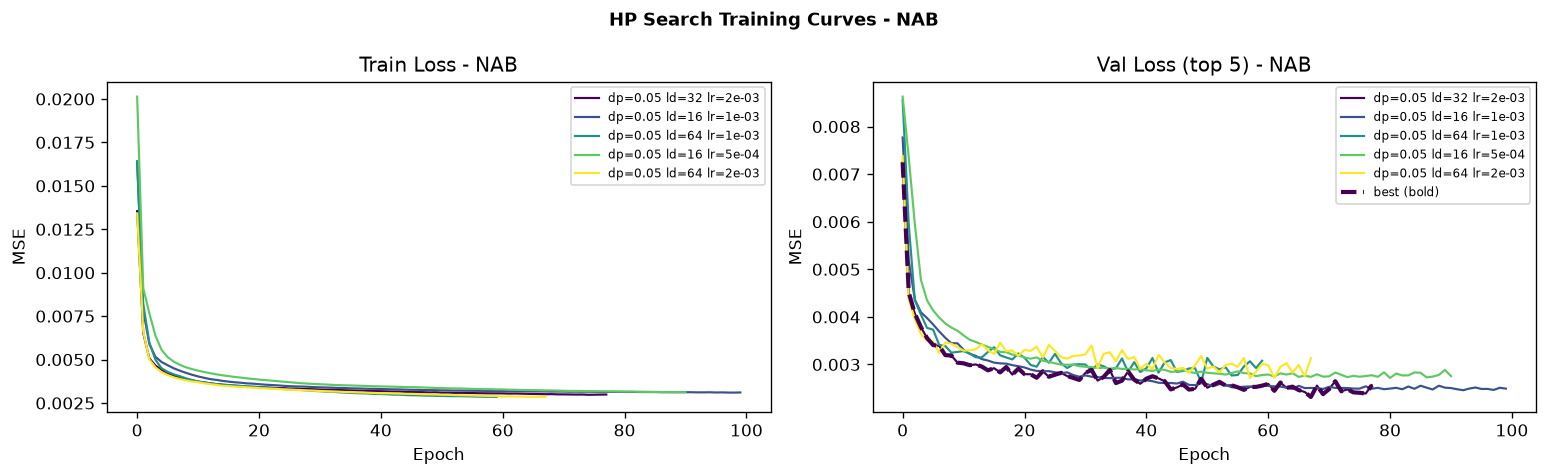

Saved outputs/m1_hp_curves_nab.png

SKAB - HP search results (27 combos)
  Rank   dropout_p  latent_dim        lr      val_loss   epochs
  ────────────────────────────────────────────────────────────
     1        0.05          64     1e-03      0.005974      100 ← best
     2        0.05          64     2e-03      0.006011      100
     3        0.05          32     2e-03      0.006156      100
     4        0.05          32     1e-03      0.006296      100
     5        0.05          64     5e-04      0.006305      100
     6        0.05          16     1e-03      0.006308      100
     7        0.05          16     2e-03      0.006411      100
     8        0.05          16     5e-04      0.006522      100
     9        0.05          32     5e-04      0.006637       91
    10        0.10          64     5e-04      0.006986      100
    11        0.10          64     2e-03      0.007086       70
    12        0.10          16     2e-03      0.007233       54
    13        0.10       

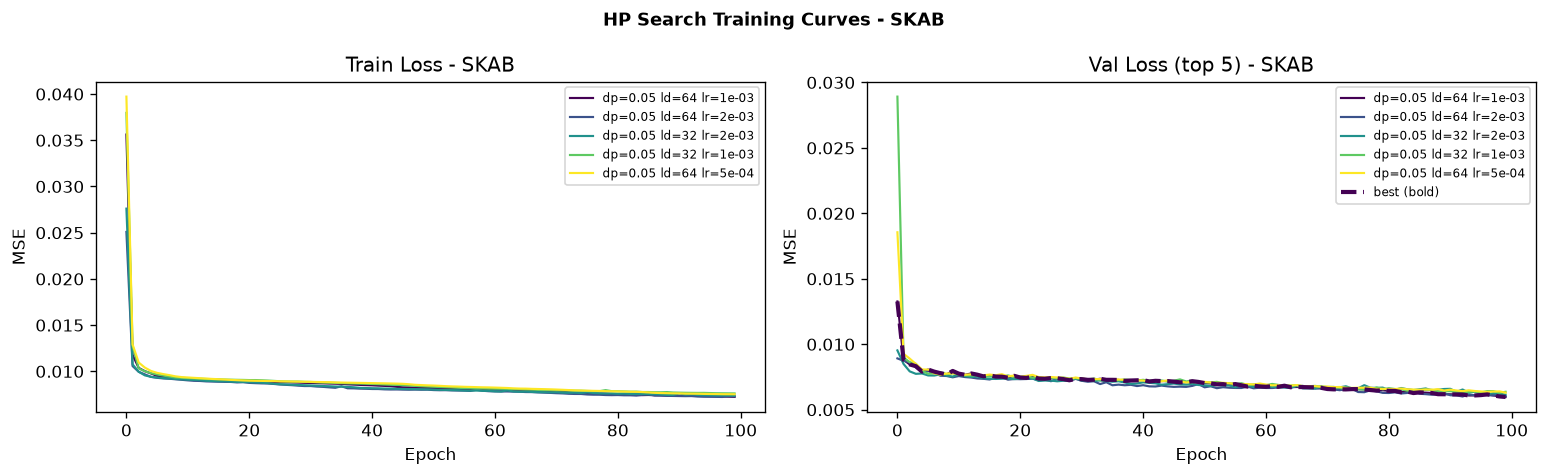

Saved outputs/m1_hp_curves_skab.png


In [11]:
# HP search results table + val-loss curves for the top-5 combos per dataset
for ds_name in sorted(sweep_results.keys()):
    res = sweep_results[ds_name]

    # ── ranked table ─────────────────────────────────────────────────────────
    ranked = sorted(res.items(), key=lambda kv: kv[1]["val_loss"])
    print(f"\n{ds_name} - HP search results ({len(ranked)} combos)")
    print(f"  {'Rank':>4}  {'dropout_p':>10}  {'latent_dim':>10}  {'lr':>8}  "
          f"{'val_loss':>12}  {'epochs':>7}")
    print(f"  {'─'*60}")
    for rank, (key, entry) in enumerate(ranked, 1):
        hp = entry["hp"]
        n  = len(entry["val_losses"])
        marker = " ← best" if rank == 1 else ""
        print(f"  {rank:>4}  {hp['dropout_p']:>10.2f}  {hp['latent_dim']:>10d}  "
              f"{hp['lr']:>8.0e}  {entry['val_loss']:>12.6f}  {n:>7}{marker}")

    # ── top-5 val-loss curves ─────────────────────────────────────────────────
    top5 = ranked[:5]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    cmap = plt.cm.viridis
    colors = [cmap(i / max(len(top5) - 1, 1)) for i in range(len(top5))]

    for (key, entry), color in zip(top5, colors):
        hp    = entry["hp"]
        label = f"dp={hp['dropout_p']} ld={hp['latent_dim']} lr={hp['lr']:.0e}"
        axes[0].plot(entry["train_losses"], color=color, lw=1.3, label=label)
        axes[1].plot(entry["val_losses"],   color=color, lw=1.3, label=label)

    # mark best
    best_key = ranked[0][0]
    best_vl  = ranked[0][1]["val_losses"]
    axes[1].plot(best_vl, color=colors[0], lw=2.5, ls="--", label="best (bold)")

    for ax, title in zip(axes, ["Train Loss", "Val Loss (top 5)"]):
        ax.set_title(f"{title} - {ds_name}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("MSE")
        ax.legend(fontsize=7, loc="upper right")

    fig.suptitle(f"HP Search Training Curves - {ds_name}", fontsize=11, fontweight="bold")
    plt.tight_layout()
    path = f"{OUTPUT_DIR}/m1_hp_curves_{ds_name.lower()}.png"
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved {path}")

In [12]:
print("=" * 70)
print("  HP SEARCH SUMMARY - best combo per dataset")
print("=" * 70)

for ds_name in sorted(best_models.keys()):
    bm = best_models[ds_name]
    hp = bm["hp"]
    print(f"\n  {ds_name}")
    print(f"  Best HP : dropout_p={hp['dropout_p']}  "
          f"latent_dim={hp['latent_dim']}  lr={hp['lr']:.0e}")
    print(f"  Val loss: {bm['val_loss']:.6f}  "
          f"({len(bm['val_losses'])} epochs)")

print("\n" + "=" * 70)

  HP SEARCH SUMMARY - best combo per dataset

  NAB
  Best HP : dropout_p=0.05  latent_dim=32  lr=2e-03
  Val loss: 0.002317  (78 epochs)

  SKAB
  Best HP : dropout_p=0.05  latent_dim=64  lr=1e-03
  Val loss: 0.005974  (100 epochs)



---
## Section 6 - MC Dropout Inference

In [13]:
mcd_results = {}   # {ds_name: {hp, val_mcd, test_mcd, train_losses, val_losses}}

for ds_name, bm in best_models.items():
    hp    = bm["hp"]
    model = bm["model"]

    print(f"\n{'='*55}")
    print(f"{ds_name} - MC Dropout  T={T_MC}  "
          f"dropout_p={hp['dropout_p']}  latent_dim={hp['latent_dim']}  lr={hp['lr']:.0e}")

    arr = data[ds_name]

    print("  Val inference ...")
    val_mcd  = mcd_scores(model, arr["X_val"],  T=T_MC)

    print("  Test inference ...")
    test_mcd = mcd_scores(model, arr["X_test"], T=T_MC)

    mcd_results[ds_name] = {
        "hp":           hp,
        "val_mcd":      val_mcd,
        "test_mcd":     test_mcd,
        "train_losses": bm["train_losses"],
        "val_losses":   bm["val_losses"],
    }
    print(f"  val  mean score : {val_mcd['mean'].mean():.5f} ± {val_mcd['mean'].std():.5f}")
    print(f"  test mean score : {test_mcd['mean'].mean():.5f} ± {test_mcd['mean'].std():.5f}")
    print(f"  test uncertainty: {test_mcd['std'].mean():.5f} (mean std across windows)")


SKAB - MC Dropout  T=50  dropout_p=0.05  latent_dim=64  lr=1e-03
  Val inference ...
  MC Dropout: 50 passes complete.          
  Test inference ...
  MC Dropout: 50 passes complete.          
  val  mean score : 0.00634 ± 0.00125
  test mean score : 0.01401 ± 0.02515
  test uncertainty: 0.00065 (mean std across windows)

NAB - MC Dropout  T=50  dropout_p=0.05  latent_dim=32  lr=2e-03
  Val inference ...
  MC Dropout: 50 passes complete.          
  Test inference ...
  MC Dropout: 50 passes complete.          
  val  mean score : 0.00294 ± 0.00754
  test mean score : 0.11670 ± 2.14898
  test uncertainty: 0.00165 (mean std across windows)


---
## Section 7 - Evaluation

In [14]:
def compute_metrics(y_true, test_scores, val_scores, thr_pct=THRESHOLD_PCT):
    """AUC-PR (primary), AUROC, F1 at val-set percentile threshold."""
    auc_pr = float(average_precision_score(y_true, test_scores))
    auroc  = float(roc_auc_score(y_true, test_scores))
    thr    = float(np.percentile(val_scores, thr_pct))
    f1     = float(f1_score(y_true, (test_scores >= thr).astype(int),
                            zero_division=0))
    return {
        "auc_pr":    round(auc_pr, 4),
        "auroc":     round(auroc,  4),
        "f1":        round(f1,     4),
        "threshold": thr,
    }


def compute_uncertainty_auroc(y_true, uncertainty_scores):
    """AUROC treating MC std as anomaly score.
    A high value means the model is more uncertain on true anomalies - good.
    """
    mask = ~np.isnan(uncertainty_scores)
    if mask.sum() < 10:
        return float("nan")
    return round(float(roc_auc_score(y_true[mask], uncertainty_scores[mask])), 4)


# ── Evaluate each dataset ──────────────────────────────────────────────────────
for ds_name, res in mcd_results.items():
    y_test   = data[ds_name]["y_test"]
    det_m    = compute_metrics(
        y_test,
        res["test_mcd"]["mean"],
        res["val_mcd"]["mean"],
    )
    auroc_unc = compute_uncertainty_auroc(y_test, res["test_mcd"]["std"])
    mcd_results[ds_name]["det_metrics"] = det_m
    mcd_results[ds_name]["auroc_unc"]   = auroc_unc

    hp = res["hp"]
    print(f"{ds_name}  dropout_p={hp['dropout_p']}  "
          f"latent_dim={hp['latent_dim']}  lr={hp['lr']:.0e}")
    print(f"  Detection:   AUC-PR={det_m['auc_pr']:.4f}  "
          f"AUROC={det_m['auroc']:.4f}  F1={det_m['f1']:.4f}")
    print(f"  Uncertainty: AUROC(std)={auroc_unc:.4f}\n")

SKAB  dropout_p=0.05  latent_dim=64  lr=1e-03
  Detection:   AUC-PR=0.7657  AUROC=0.5470  F1=0.4186
  Uncertainty: AUROC(std)=0.4015

NAB  dropout_p=0.05  latent_dim=32  lr=2e-03
  Detection:   AUC-PR=0.4631  AUROC=0.5934  F1=0.3182
  Uncertainty: AUROC(std)=0.5835



In [15]:
# Load B3 baseline results for comparison
try:
    with open(RESULTS_FILE) as f:
        baseline_results = json.load(f)
    print(f"Loaded baseline results from {RESULTS_FILE}")
except FileNotFoundError:
    baseline_results = {}
    print("WARNING: baseline_results.json not found - B3 column will be empty.")

rows = []
for ds_name in sorted(data.keys()):
    # B3 row
    b3 = baseline_results.get(ds_name, {}).get("B3_denseae", {}).get("metrics", {})
    rows.append({
        "Dataset":    ds_name,
        "Method":     "B3 - Dense AE (det.)",
        "HP":         "-",
        "AUC-PR":     b3.get("auc_pr", float("nan")),
        "AUROC":      b3.get("auroc",  float("nan")),
        "F1":         b3.get("f1",     float("nan")),
        "AUROC(unc)": float("nan"),
    })
    # M1 row
    m1  = mcd_results.get(ds_name, {})
    dm  = m1.get("det_metrics", {})
    hp  = m1.get("hp", {})
    hp_str = (f"dp={hp.get('dropout_p','?')} ld={hp.get('latent_dim','?')} "
              f"lr={hp.get('lr', 0):.0e}") if hp else "-"
    rows.append({
        "Dataset":    ds_name,
        "Method":     "M1 - Dense AE + MCD",
        "HP":         hp_str,
        "AUC-PR":     dm.get("auc_pr",  float("nan")),
        "AUROC":      dm.get("auroc",   float("nan")),
        "F1":         dm.get("f1",      float("nan")),
        "AUROC(unc)": m1.get("auroc_unc", float("nan")),
    })

comp_df = pd.DataFrame(rows).set_index(["Dataset", "Method"])
print(comp_df.to_string())
print()
display(
    comp_df.style
    .background_gradient(subset=["AUC-PR"],     cmap="Greens")
    .background_gradient(subset=["AUROC"],       cmap="Blues")
    .background_gradient(subset=["F1"],          cmap="Oranges")
    .background_gradient(subset=["AUROC(unc)"],  cmap="Purples")
    .format("{:.4f}", subset=["AUC-PR","AUROC","F1","AUROC(unc)"], na_rep="-")
)

Loaded baseline results from outputs/baseline_results.json
                                                  HP  AUC-PR   AUROC      F1  AUROC(unc)
Dataset Method                                                                          
NAB     B3 - Dense AE (det.)                       -  0.4672  0.6012  0.3183         NaN
        M1 - Dense AE + MCD   dp=0.05 ld=32 lr=2e-03  0.4631  0.5934  0.3182      0.5835
SKAB    B3 - Dense AE (det.)                       -  0.7960  0.6105  0.3914         NaN
        M1 - Dense AE + MCD   dp=0.05 ld=64 lr=1e-03  0.7657  0.5470  0.4186      0.4015



---
## Section 8 - Visualisations

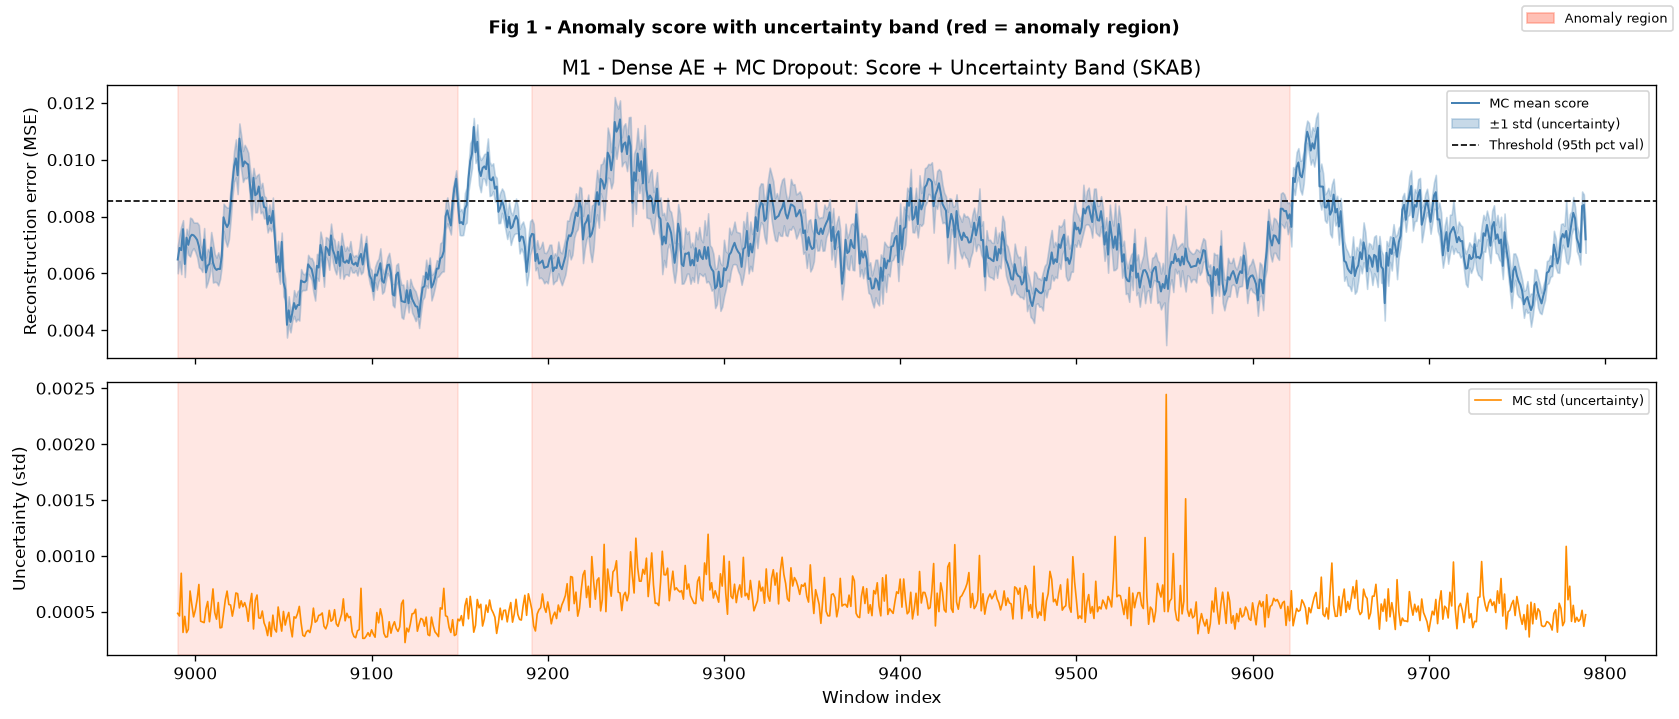

Saved outputs/fig1_m1_score_uncertainty_skab.png


In [ ]:
# Fig 1 - Anomaly score + uncertainty band over time (SKAB)
# Shows a window that spans a normal → anomaly transition
if "SKAB" in mcd_results:
    y_test   = data["SKAB"]["y_test"]
    mean_s   = mcd_results["SKAB"]["test_mcd"]["mean"]
    std_s    = mcd_results["SKAB"]["test_mcd"]["std"]
    thr      = mcd_results["SKAB"]["det_metrics"]["threshold"]

    # Find first normal→anomaly transition; show 200 steps before + 600 after
    transitions = np.where(np.diff(y_test.astype(int)) == 1)[0]
    t0 = int(max(0,             transitions[0] - 200)) if len(transitions) else 0
    t1 = int(min(len(y_test),   t0 + 800))
    idx = np.arange(t0, t1)

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

    def shade_regions(ax, idx, labels):
        in_a, start = False, None
        for i, lab in zip(idx, labels):
            if lab == 1 and not in_a:
                start, in_a = i, True
            elif lab == 0 and in_a:
                ax.axvspan(start, i, alpha=0.15, color="tomato", zorder=0)
                in_a = False
        if in_a:
            ax.axvspan(start, idx[-1], alpha=0.15, color="tomato", zorder=0)

    # Top panel - anomaly score + uncertainty band
    ax0 = axes[0]
    ax0.plot(idx, mean_s[t0:t1], color="steelblue", lw=1.2, label="MC mean score")
    ax0.fill_between(
        idx,
        mean_s[t0:t1] - std_s[t0:t1],
        mean_s[t0:t1] + std_s[t0:t1],
        alpha=0.30, color="steelblue", label="±1 std (uncertainty)",
    )
    ax0.axhline(thr, color="black", ls="--", lw=1.0,
                label=f"Threshold ({THRESHOLD_PCT}th pct val)")
    shade_regions(ax0, idx, y_test[t0:t1])
    ax0.set_ylabel("Reconstruction error (MSE)")
    ax0.set_title("M1 - Dense AE + MC Dropout: Score + Uncertainty Band (SKAB)")
    ax0.legend(fontsize=8)

    # Bottom panel - uncertainty only
    ax1 = axes[1]
    ax1.plot(idx, std_s[t0:t1], color="darkorange", lw=1.0, label="MC std (uncertainty)")
    shade_regions(ax1, idx, y_test[t0:t1])
    ax1.set_ylabel("Uncertainty (std)")
    ax1.set_xlabel("Window index")
    ax1.legend(fontsize=8)

    from matplotlib.patches import Patch
    fig.legend(
        handles=[Patch(color="tomato", alpha=0.4, label="Anomaly region")],
        loc="upper right", fontsize=8,
    )
    fig.suptitle("Anomaly score with uncertainty band (red = anomaly region)",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    path = f"{OUTPUT_DIR}/fig1_m1_score_uncertainty_skab.png"
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved {path}")
else:
    print("SKAB not in results - skipping Fig 1.")

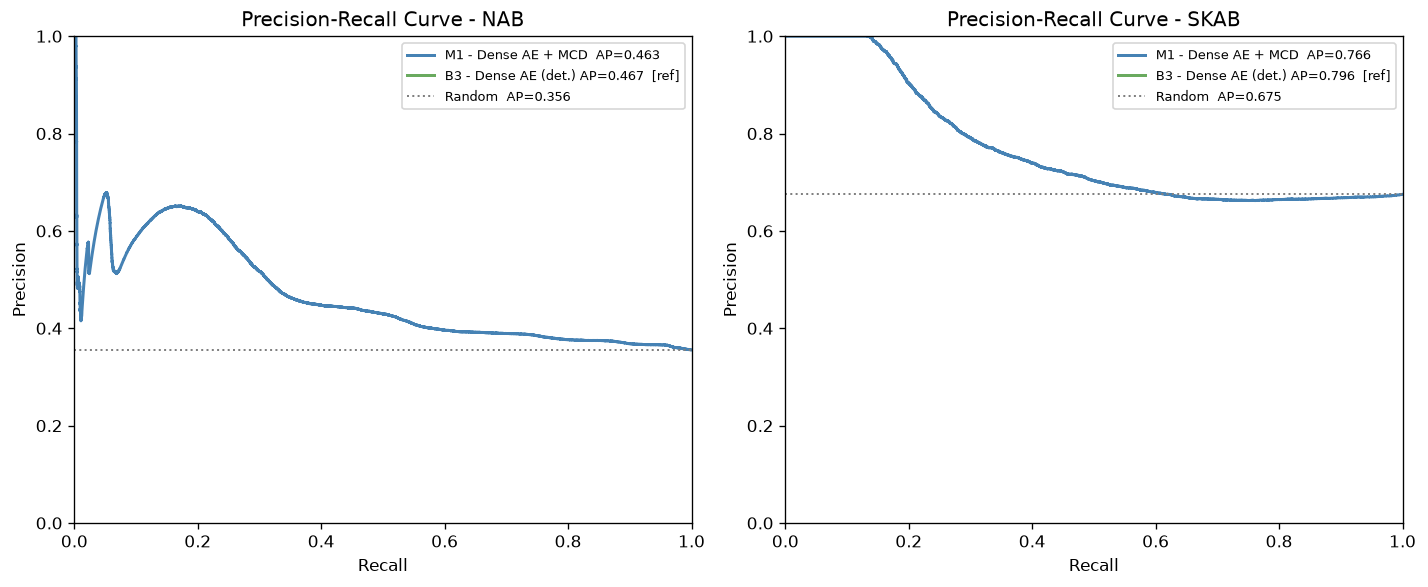

Saved outputs/m1_pr_curves.png


In [17]:
# Precision-Recall curves - one subplot per dataset
n_ds  = len(mcd_results)
fig, axes = plt.subplots(1, n_ds, figsize=(6 * n_ds, 5))
if n_ds == 1:
    axes = [axes]

for ax, ds_name in zip(axes, sorted(mcd_results.keys())):
    y_test     = data[ds_name]["y_test"]
    mean_score = mcd_results[ds_name]["test_mcd"]["mean"]

    # M1 PR curve
    prec, rec, _ = precision_recall_curve(y_test, mean_score)
    m1_ap = mcd_results[ds_name]["det_metrics"]["auc_pr"]
    ax.plot(rec, prec, color="steelblue", lw=1.8,
            label=f"M1 - Dense AE + MCD  AP={m1_ap:.3f}")

    # B3 reference (AP only - raw scores not available in this notebook)
    b3_ap = (baseline_results.get(ds_name, {})
             .get("B3_denseae", {}).get("metrics", {}).get("auc_pr", None))
    if b3_ap:
        ax.plot([], [], color="#6aaa5f", lw=1.8,
                label=f"B3 - Dense AE (det.) AP={b3_ap:.3f}  [ref]")

    # Random baseline
    anom_rate = float(y_test.mean())
    ax.axhline(anom_rate, color="grey", ls=":", lw=1.2,
               label=f"Random  AP={anom_rate:.3f}")

    ax.set_title(f"Precision-Recall Curve - {ds_name}")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

plt.tight_layout()
path = f"{OUTPUT_DIR}/m1_pr_curves.png"
plt.savefig(path, bbox_inches="tight")
plt.show()
print(f"Saved {path}")

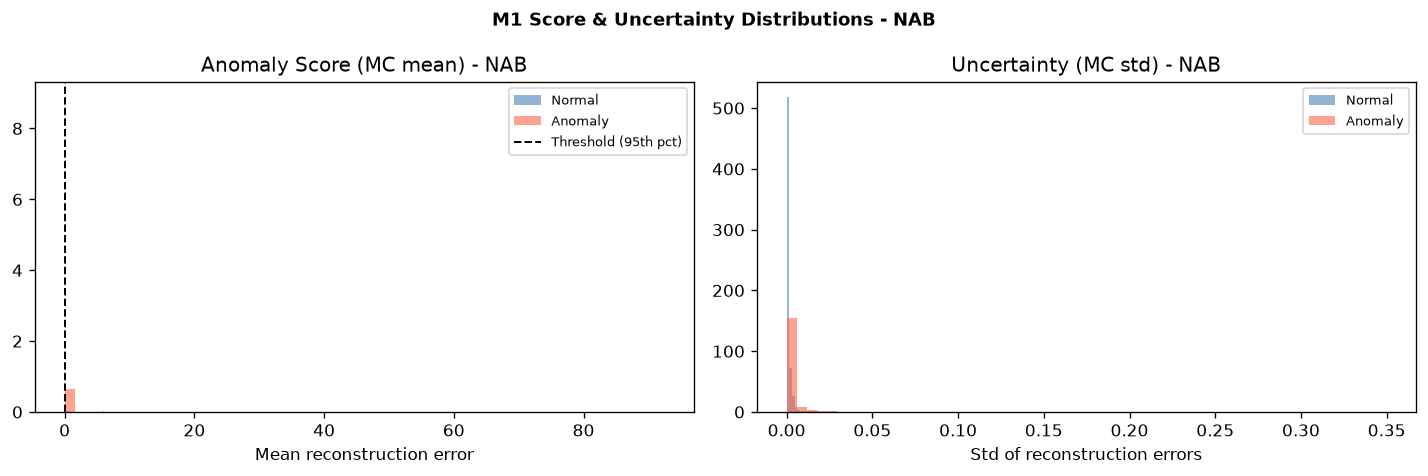

Saved outputs/m1_distributions_nab.png


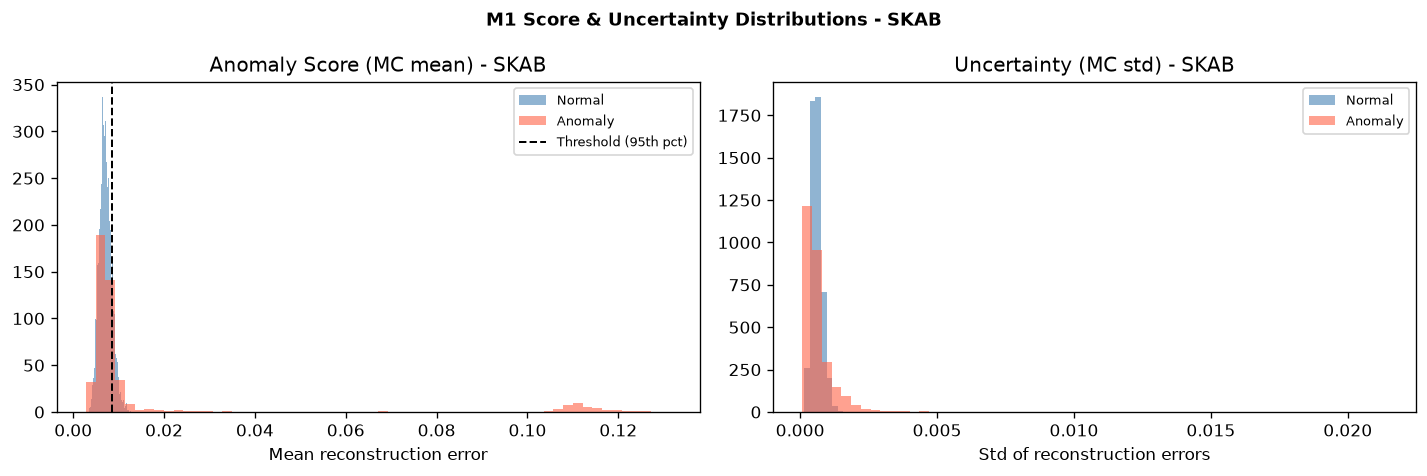

Saved outputs/m1_distributions_skab.png


In [18]:
# Score and uncertainty distributions - normal vs anomaly
for ds_name in sorted(mcd_results.keys()):
    y_test     = data[ds_name]["y_test"]
    mean_score = mcd_results[ds_name]["test_mcd"]["mean"]
    std_score  = mcd_results[ds_name]["test_mcd"]["std"]
    thr        = mcd_results[ds_name]["det_metrics"]["threshold"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: anomaly score distribution
    ax = axes[0]
    ax.hist(mean_score[y_test == 0], bins=60, alpha=0.6, density=True,
            color="steelblue", label="Normal")
    ax.hist(mean_score[y_test == 1], bins=60, alpha=0.6, density=True,
            color="tomato",    label="Anomaly")
    ax.axvline(thr, color="black", ls="--", lw=1.2,
               label=f"Threshold ({THRESHOLD_PCT}th pct)")
    ax.set_title(f"Anomaly Score (MC mean) - {ds_name}")
    ax.set_xlabel("Mean reconstruction error")
    ax.legend(fontsize=8)

    # Right: uncertainty distribution
    ax2 = axes[1]
    ax2.hist(std_score[y_test == 0], bins=60, alpha=0.6, density=True,
             color="steelblue", label="Normal")
    ax2.hist(std_score[y_test == 1], bins=60, alpha=0.6, density=True,
             color="tomato",    label="Anomaly")
    ax2.set_title(f"Uncertainty (MC std) - {ds_name}")
    ax2.set_xlabel("Std of reconstruction errors")
    ax2.legend(fontsize=8)

    fig.suptitle(f"M1 Score & Uncertainty Distributions - {ds_name}",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    path = f"{OUTPUT_DIR}/m1_distributions_{ds_name.lower()}.png"
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved {path}")

---
## Section 9 - Save Results

In [19]:
# Load existing results (created by notebook 03)
try:
    with open(RESULTS_FILE) as f:
        all_results = json.load(f)
except FileNotFoundError:
    all_results = {}
    print("WARNING: baseline_results.json not found - creating fresh.")

# Append M1 results
for ds_name, res in mcd_results.items():
    if ds_name not in all_results:
        all_results[ds_name] = {}
    dm = res["det_metrics"]
    hp = res["hp"]
    all_results[ds_name]["M1_dense_mcd"] = {
        "hp": hp,
        "metrics": {
            "auc_pr":    dm["auc_pr"],
            "auroc":     dm["auroc"],
            "f1":        dm["f1"],
            "threshold": dm["threshold"],
            "auroc_unc": res["auroc_unc"],
        },
        "train_losses": res["train_losses"],
        "val_losses":   res["val_losses"],
    }

with open(RESULTS_FILE, "w") as f:
    json.dump(all_results, f, indent=2)

print(f"Results saved → {RESULTS_FILE}")
print("Keys in results file:")
for ds_name, methods in all_results.items():
    print(f"  {ds_name}: {list(methods.keys())}")

Results saved → outputs/baseline_results.json
Keys in results file:
  SKAB: ['B1_zscore', 'B2_isoforest', 'B3_denseae', 'M3_dense_cp', 'M4_lstm_cp', 'M2b_lstm_mcd_lowdrop', 'M1_dense_mcd']
  NAB: ['B1_zscore', 'B2_isoforest', 'B3_denseae', 'M3_dense_cp', 'M4_lstm_cp', 'M2b_lstm_mcd_lowdrop', 'M1_dense_mcd']


In [20]:
print("=" * 72)
print("  M1 - Dense AE + MC Dropout  FINAL SUMMARY")
print("=" * 72)

for ds_name in sorted(mcd_results.keys()):
    res = mcd_results[ds_name]
    dm  = res["det_metrics"]
    hp  = res["hp"]
    b3  = (baseline_results.get(ds_name, {})
           .get("B3_denseae", {}).get("metrics", {}))

    print(f"\n  {ds_name}")
    print(f"  Best HP : dropout_p={hp['dropout_p']}  "
          f"latent_dim={hp['latent_dim']}  lr={hp['lr']:.0e}")
    print(f"  {'Metric':<22} {'B3 (det.)':>12} {'M1 (MCD)':>12} {'Delta':>9}")
    print(f"  {'─'*58}")

    for key, label in [("auc_pr", "AUC-PR"), ("auroc", "AUROC"), ("f1", "F1")]:
        b3v = b3.get(key, float("nan"))
        m1v = dm.get(key, float("nan"))
        dlt = m1v - b3v
        sgn = "+" if dlt >= 0 else ""
        print(f"  {label:<22} {b3v:>12.4f} {m1v:>12.4f} {sgn}{dlt:>8.4f}")

    print(f"  {'AUROC(uncertainty)':<22} {'-':>12} {res['auroc_unc']:>12.4f} {'-':>9}")

print("\n" + "=" * 72)
print(f"\n  Plots   → {OUTPUT_DIR}/")
print(f"  Models  → {CKPT_DIR}/")
if PUSH_TO_HUB:
    print(f"  HF Hub  → https://huggingface.co/{MODEL_REPO_ID}/tree/main/checkpoints")
print(f"  Results → {RESULTS_FILE}")
print("=" * 72)

  M1 - Dense AE + MC Dropout  FINAL SUMMARY

  NAB
  Best HP : dropout_p=0.05  latent_dim=32  lr=2e-03
  Metric                    B3 (det.)     M1 (MCD)     Delta
  ──────────────────────────────────────────────────────────
  AUC-PR                       0.4672       0.4631  -0.0041
  AUROC                        0.6012       0.5934  -0.0078
  F1                           0.3183       0.3182  -0.0001
  AUROC(uncertainty)                -       0.5835         -

  SKAB
  Best HP : dropout_p=0.05  latent_dim=64  lr=1e-03
  Metric                    B3 (det.)     M1 (MCD)     Delta
  ──────────────────────────────────────────────────────────
  AUC-PR                       0.7960       0.7657  -0.0303
  AUROC                        0.6105       0.5470  -0.0635
  F1                           0.3914       0.4186 +  0.0272
  AUROC(uncertainty)                -       0.4015         -


  Plots   → outputs/
  Models  → models/checkpoints/
  HF Hub  → https://huggingface.co/ayyoubsoullami/iot-a